In [ ]:

!pip install scikit-learn


  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.7 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.7 MB 385.3 kB/s eta 0:00:22
   -- ------------------------------------- 0.5/8.7 MB 385.3 kB/s eta 0:00:22
   -- ------------------------------------- 0.5/8.7 MB 385.3 kB/s eta 0:00:22
   --- ------------------------------------ 0.8/8.7 MB 349.7 kB/s eta 0:00:23
   --- ------------------------------------ 0.8/8.7 MB 349.7 kB/s e

In [11]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering, KMeans
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform

In this problem, you will generate simulated data, and then perform
 PCA and K-means clustering on the data.
 (a) Generate a simulated data set with 20 observations in each of
 three classes (i.e. 60 observations total), and 50 variables.
 Hint: There are a number of functions in Python that you can
 use to generate data. One example is the normal() method of
 the random() function in numpy; the uniform() method is another
 option. Be sure to add a mean shift to the observations in each
 class so that there are three distinct classes.

In [3]:
np.random.seed(0)
data = np.random.normal(size=(60,50))
data[:20, :] = data[:20, :] + 1
data[40:, :] = data[40:, :] - 1

In [5]:
real_cluster = np.zeros((60, ))
real_cluster[20:40] = real_cluster[20:40] + 1
real_cluster[40:] = real_cluster[40:] + 2

(b) Perform PCA on the 60 observations and plot the first two prin
cipal component score vectors. Use a different color to indicate
 the observations in each of the three classes. If the three classes
 appear separated in this plot, then continue on to part (c). If
 not, then return to part (a) and modify the simulation so that
 there is greater separation between the three classes. Do not
 continue to part (c) until the three classes show at least some
 separation in the first two principal component score vectors.

Text(0, 0.5, 'Second  Component')

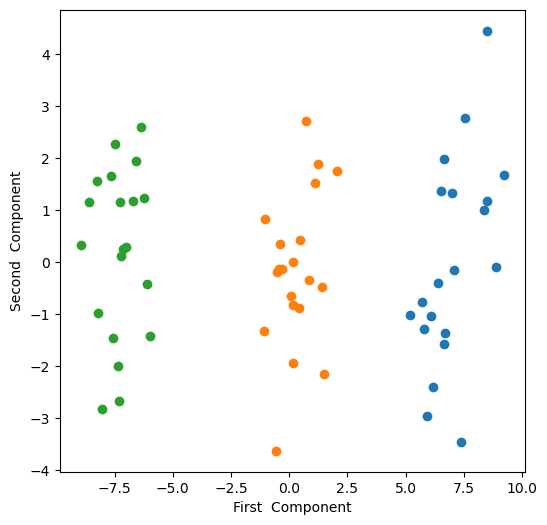

In [13]:
pca = PCA()
pca.fit(data)

scores = pca.transform(data)[:, :2]
plt.figure(figsize=(6,6))
plt.scatter(scores[:20, 0], scores[:20, 1])
plt.scatter(scores[20:40, 0], scores[20:40, 1])
plt.scatter(scores[40:, 0], scores[40:, 1])
plt.xlabel('First  Component')
plt.ylabel('Second  Component')

(c) Perform K-means clustering of the observations with K = 3.
 How well do the clusters that you obtained in K-means cluster
ing compare to the true class labels?
 Hint: You can use the pd.crosstab() function in Python to com
pare the true class labels to the class labels obtained by cluster
ing. Be careful how you interpret the results: K-means clustering
 will arbitrarily number the clusters, so you cannot simply check
 whether the true class labels and clustering labels are the same.

In [14]:
kmeans = KMeans(n_clusters=3, n_init=20)
kmeans.fit(data)

c:\Users\Acer\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,3
,init,'k-means++'
,n_init,20
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [15]:
pd.crosstab(kmeans.labels_, real_cluster)

col_0,0.0,1.0,2.0
row_0,,,
0,0,20,0
1,20,0,0
2,0,0,20


(d) Perform K-means clustering with K = 2. Describe your results.

In [16]:
kmeans2 = KMeans(n_clusters=2, n_init=20)
kmeans2.fit(data)
pd.crosstab(kmeans2.labels_, real_cluster)

c:\Users\Acer\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


col_0,0.0,1.0,2.0
row_0,,,
0,0,0,20
1,20,20,0


First 2 classes are clustered in one cluster and the third is in one different cluster.

(e) Now perform K-means clustering with K = 4, and describe your
 results.

In [17]:
kmeans3 = KMeans(n_clusters=4, n_init=20)
kmeans3.fit(data)
pd.crosstab(kmeans3.labels_, real_cluster)

c:\Users\Acer\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


col_0,0.0,1.0,2.0
row_0,,,
0,0,0,11
1,20,0,0
2,0,0,9
3,0,20,0


The first two classes are clustered well but the last third one is not well clustered.

(f) Now perform K-means clustering with K = 3 on the first two
 principal component score vectors, rather than on the raw data.
 That is, perform K-means clustering on the 60 × 2 matrix of
 which the first column is the first principal component score
 vector, and the second column is the second principal component
 score vector. Comment on the results.

In [18]:
kmeans4 = KMeans(n_clusters=3, n_init=20)
kmeans4.fit(scores)
pd.crosstab(kmeans4.labels_, real_cluster)

c:\Users\Acer\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


col_0,0.0,1.0,2.0
row_0,,,
0,0,0,20
1,20,0,0
2,0,20,0


The algorithm successfully separates the observations using the information from the component scores obtained from the PCA algorithm.

(g) Using the StandardScaler() estimator, perform K-means clus
tering with K = 3 on the data after scaling each variable to have
 standard deviation one. How do these results compare to those
 obtained in (b)? Explain.

In [20]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)
kmeans5 = KMeans(n_clusters=3, n_init=20)
kmeans5.fit(data_scaled)
pd.crosstab(kmeans5.labels_, real_cluster)

c:\Users\Acer\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


col_0,0.0,1.0,2.0
row_0,,,
0,0,20,0
1,0,0,20
2,20,0,0


This method separated the data in 3 clusters; however, it assigned different labels to the first and second classes compared to  initial clustering.